## Lecture 01 - Introduction to NumPy and Shape Analysis

### Why NumPy?

Images contain millions of pixels. Processing them using pure Python loops is highly inefficient because Python processes each element sequentially with massive overhead. **NumPy (Numeric Python)** provides **vectorization**, allowing us to perform mathematical operations on entire arrays simultaneously at C-speed without writing loops.

---

In [1]:
import numpy as np
import time

# ---------------------------------------------------------
# 1. Comparing Pure Python Loops vs. NumPy Vectorization
# ---------------------------------------------------------

# Generate 10 million random pixel intensity values
size = 10_000_000
xs = np.random.rand(size) # Vectorized generation

# Benchmark Pure Python Loop
start_time = time.time()
ys_python = []
for x in xs:
    ys_python.append(3 * x + 4) # Applying y = 3x + 4 sequentially
python_duration = time.time() - start_time

# Benchmark NumPy Vectorization
start_time = time.time()
ys_numpy = xs * 3 + 4 # Applying y = 3x + 4 in parallel across the entire array
numpy_duration = time.time() - start_time

print(f"Python Loop Time: {python_duration:.4f} seconds")
print(f"NumPy Vectorized Time: {numpy_duration:.4f} seconds")
print(f"NumPy is roughly {python_duration / numpy_duration:.1f}x faster!")

Python Loop Time: 1.6287 seconds
NumPy Vectorized Time: 0.0388 seconds
NumPy is roughly 42.0x faster!


---

### Understanding Array Creation: Python Lists vs. NumPy Arrays

A standard Python list performs element concatenation when using the `+` operator, whereas a NumPy array performs actual element-wise addition.

In [2]:
# Standard Python Lists
a_list = [3, 4, 5]
b_list = [6, 7, 8]
print(f"Original Python List Addition: {a_list + b_list}") # Concatenates

# NumPy Arrays
a_arr = np.array(a_list)
b_arr = np.array(b_list)
print(f"Updated NumPy Array Addition: {a_arr + b_arr}") # Element-wise sum


Original Python List Addition: [3, 4, 5, 6, 7, 8]
Updated NumPy Array Addition: [ 9 11 13]


---

### Reading and Interpreting Tensor Shapes

In machine learning frameworks, data matrices are called **Tensors**. To read an image tensor shape, evaluate the dimensions from left to right:

* **3D Tensor Structure:** `(Channels, Height, Width)` $\rightarrow$ `Channels=3` for RGB images, and `Channels=1` for Grayscale images.
* **4D Tensor Structure:** `(Batch_Dim, Channels, Height, Width)` $\rightarrow$ The first dimension always indicates the number of images processed together in a single batch.

In [3]:
# ---------------------------------------------------------
# 2. Analyzing Multi-Dimensional Tensor Shapes
# ---------------------------------------------------------

# Generate a mock batch of 4 RGB images, each with a size of 2x2 pixels
# Shape layout: [Batch_Size, Channels, Height, Width]
batch_of_images = np.random.randint(0, 10, (4, 3, 2, 2))

print(f"Full Batch Tensor Shape: {batch_of_images.shape}")
print(f"Total Dimensions: {batch_of_images.ndim}")
print(f"First Dimension (Batch Size): {batch_of_images.shape[0]}")

print("\n--- Accessing Individual Image Tensors inside the Batch ---")
print(f"Image 1 Shape: {batch_of_images[0].shape}") # Yields the (C, H, W) of index 0
print(f"Image 2 Shape: {batch_of_images[1].shape}")

Full Batch Tensor Shape: (4, 3, 2, 2)
Total Dimensions: 4
First Dimension (Batch Size): 4

--- Accessing Individual Image Tensors inside the Batch ---
Image 1 Shape: (3, 2, 2)
Image 2 Shape: (3, 2, 2)


### Day 2 — Common Array Initializers in NumPy

NumPy provides native functions to instantly construct arrays with specific shapes and default value configurations without writing standard loop boilerplate.

In [4]:
import numpy as np

# 1. Constant Value Initializations
zeros_mat = np.zeros(shape=(3, 3))            # 3x3 Matrix filled with 0.0
ones_mat = np.ones(shape=(2, 2))              # 2x2 Matrix filled with 1.0 (often used for gradient masking)
five_mat = np.full(shape=(2, 2), fill_value=5) # 2x2 Matrix filled with a custom target value (5)
identity_mat = np.eye(3)                      # 3x3 Identity Matrix with diagonal 1s

# 2. Random Distribution Generators
rand_uniform = np.random.rand(3, 4)           # Uniformly distributed values between [0, 1)
rand_normal = np.random.randn(3, 4)           # Standard Normal distribution (Mean = 0, Std = 1)

print("--- Distribution Analysis Check ---")
print(f"Uniform distribution -> Mean: {rand_uniform.mean():.2f} | Std: {rand_uniform.std():.2f}")
print(f"Normal distribution  -> Mean: {rand_normal.mean():.2f} | Std: {rand_normal.std():.2f}\n")

# 3. Step and Interval Sequences
step_range = np.arange(start=13, stop=50, step=2)  # Generates odd numbers up to (but excluding) 50
linear_space = np.linspace(start=0, stop=1, num=5) # 5 evenly spaced numbers dividing the range [0, 1]

print(f"arange sequence: {step_range}")
print(f"linspace divisions: {linear_space}")

--- Distribution Analysis Check ---
Uniform distribution -> Mean: 0.62 | Std: 0.30
Normal distribution  -> Mean: -0.02 | Std: 1.20

arange sequence: [13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47 49]
linspace divisions: [0.   0.25 0.5  0.75 1.  ]


#### Dimensionality Nomenclature: Physics vs. Machine Learning

To maintain absolute structural clarity, machine learning drops classic descriptive terms like *scalar*, *vector*, or *matrix* and classifies arrays strictly by their total coordinate axes as **$n$-Dimensional Tensors**.

| Physical Data Structure | Deep Learning Tensor Convention |
| :--- | :--- |
| `3` (Single Scalar) | **0D Tensor** |
| `[3, 4]` (1D Array/Vector) | **1D Tensor** |
| `[[1, 2], [5, 3]]` (2D Grid/Matrix) | **2D Tensor** |
| `[[[4, 2], [3, 1]], [[6, 2], [7, -2]]]` (3D Volume) | **3D Tensor** |

In [5]:
# Verifying dimensions (.ndim) using Machine Learning tensor conventions
tensor_4d = np.random.rand(2, 3, 4, 5) # 4D Tensor (e.g., Image Batches)
tensor_3d = np.random.rand(2, 3, 4)    # 3D Tensor (e.g., Sequence/Text Embeddings)
tensor_2d = np.random.rand(2, 3)       # 2D Tensor (e.g., Tabular Rows/Features)
tensor_1d = np.random.rand(3)          # 1D Tensor (e.g., Layer Biases)
scalar_0d = np.array(3)                # 0D Tensor (e.g., Evaluation Metrics / Total Loss)

print(f"tensor_4d dimensions: {tensor_4d.ndim}-D")
print(f"tensor_3d dimensions: {tensor_3d.ndim}-D")
print(f"tensor_2d dimensions: {tensor_2d.ndim}-D")
print(f"tensor_1d dimensions: {tensor_1d.ndim}-D")
print(f"scalar_0d dimensions: {scalar_0d.ndim}-D")

tensor_4d dimensions: 4-D
tensor_3d dimensions: 3-D
tensor_2d dimensions: 2-D
tensor_1d dimensions: 1-D
scalar_0d dimensions: 0-D


#### Core Tensor Inspection Properties

Before passing data tensors into deep learning layers, we must inspect their shapes, structural volume, and data storage types to avoid tensor incompatibility runtime errors.

In [6]:
# Sample 3D Tensor initialization
sample_tensor = np.random.randint(0, 10, size=(1, 5, 6))

# Essential metadata retrieval attributes
print(f"1. .shape : {sample_tensor.shape}") # Dimensions layout configuration
print(f"2. .ndim  : {sample_tensor.ndim}")  # Absolute number of data axes
print(f"3. .size  : {sample_tensor.size}")  # Multiplied total number of individual elements (1 * 5 * 6)
print(f"4. .dtype : {sample_tensor.dtype}") # Memory data type block (e.g., int32, float64)

1. .shape : (1, 5, 6)
2. .ndim  : 3
3. .size  : 30
4. .dtype : int32


#### Fundamental Shape Transformations

Modifying the shape of an array is a routine operation in image processing. NumPy allows us to adjust array dimensions, flatten multidimensional matrices, or compute matrix transposes.

In [7]:
# Create a baseline 1D vector of 6 elements
base_vector = np.array([1, 2, 3, 4, 5, 6])
print(f"Original 1D Vector: {base_vector} | Shape: {base_vector.shape}\n")

# 1. Reshaping (Altering layout without changing underlying element count)
reshaped_matrix = base_vector.reshape(2, 3)
print("--- After .reshape(2, 3) ---")
print(reshaped_matrix)
print(f"New Matrix Shape: {reshaped_matrix.shape}\n")

# 2. Transposition (Swapping rows with columns)
transposed_matrix = reshaped_matrix.T
print("--- After .T (Transpose) ---")
print(transposed_matrix)
print(f"Transposed Shape: {transposed_matrix.shape}\n")

# 3. Flattening (Collapsing multi-dimensional structures back into a 1D vector)
flattened_vector = transposed_matrix.flatten()
print("--- After .flatten() ---")
print(flattened_vector)
print(f"Flattened Shape: {flattened_vector.shape}")

Original 1D Vector: [1 2 3 4 5 6] | Shape: (6,)

--- After .reshape(2, 3) ---
[[1 2 3]
 [4 5 6]]
New Matrix Shape: (2, 3)

--- After .T (Transpose) ---
[[1 4]
 [2 5]
 [3 6]]
Transposed Shape: (3, 2)

--- After .flatten() ---
[1 4 2 5 3 6]
Flattened Shape: (6,)


### Day 3 — Array Operations and Broadcasting

Today we transition from static shape analysis to dynamic array manipulation. We will cover:
1. **Indexing and Slicing:** Extracting sub-grids, rows, columns, and target pixel patches from multi-dimensional arrays.
2. **Element-wise Operations:** Performing vectorized math seamlessly across matching matrices.
3. **Broadcasting:** Understanding the core rules that allow NumPy to perform arithmetic on arrays with different but compatible shapes.

#### 1. Indexing and Slicing

Slicing allows you to target specific coordinates or sub-regions within a tensor without making memory copies. NumPy uses the `[start:stop:step]` syntax across multiple dimensions separated by commas: `[row_slice, column_slice]`.

In [8]:
import numpy as np

# Simulate a 4D batch tensor: 2 images, 3 color channels (RGB), 3x3 pixel grid
img_batch = np.random.randint(0, 10, (2, 3, 3, 3))
print("--- Full Original Image Batch Tensor ---")
print(img_batch)

print("\n-------------------------------------------------------------")
print("Slice 1: Advanced Axis Striding -> img_batch[:, :2, :, 0::2]")
print("-------------------------------------------------------------")
# Meaning: Keep all images, slice the first two color channels (R & G), 
# keep all rows, but step through columns by skipping every second pixel (downsampling).
print(img_batch[:, :2, :, 0::2])

print("\n-------------------------------------------------------------")
print("Slice 2: Targeted Channel Extraction -> img_batch[:, 1]")
print("-------------------------------------------------------------")
# Meaning: Keep all image batches, but cleanly isolate the second channel index (Green Channel).
green_channel_extraction = img_batch[:, 1]
print(green_channel_extraction)
print(f"Shape after channel extraction: {green_channel_extraction.shape}")

print("\n-------------------------------------------------------------")
print("Slice 3: Spatial Bounding Patch Downsampling")
print("-------------------------------------------------------------")
# Meaning: Keep all batches and color layers, but slice odd row and column indices.
print(img_batch[:, :, 1::2, 1::2])

--- Full Original Image Batch Tensor ---
[[[[7 0 0]
   [5 4 1]
   [5 9 0]]

  [[8 1 4]
   [0 5 5]
   [0 3 4]]

  [[4 1 3]
   [6 5 6]
   [1 1 0]]]


 [[[1 1 6]
   [9 0 7]
   [4 3 9]]

  [[5 5 6]
   [9 6 2]
   [9 3 9]]

  [[1 0 9]
   [6 9 9]
   [9 3 4]]]]

-------------------------------------------------------------
Slice 1: Advanced Axis Striding -> img_batch[:, :2, :, 0::2]
-------------------------------------------------------------
[[[[7 0]
   [5 1]
   [5 0]]

  [[8 4]
   [0 5]
   [0 4]]]


 [[[1 6]
   [9 7]
   [4 9]]

  [[5 6]
   [9 2]
   [9 9]]]]

-------------------------------------------------------------
Slice 2: Targeted Channel Extraction -> img_batch[:, 1]
-------------------------------------------------------------
[[[8 1 4]
  [0 5 5]
  [0 3 4]]

 [[5 5 6]
  [9 6 2]
  [9 3 9]]]
Shape after channel extraction: (2, 3, 3)

-------------------------------------------------------------
Slice 3: Spatial Bounding Patch Downsampling
----------------------------------------------

### 2. Element-wise Operations

When two tensors share the exact same dimensions, any standard arithmetic operator (`+`, `-`, `*`, `/`) automatically executes element-by-element across matching indices in parallel.

In [9]:
# Initialize two identical 3x3 matrices containing random integer values
matrix_A = np.random.randint(1, 6, (3, 3))
matrix_B = np.random.randint(1, 6, (3, 3))

print("Matrix A:\n", matrix_A)
print("Matrix B:\n", matrix_B)

# 1. Element-wise Matrix Multiplication (Hadamard Product)
# Note: This is NOT dot-product matrix multiplication; elements at identical indices are multiplied.
hadamard_product = matrix_A * matrix_B
print("\nVectorized Hadamard Product (A * B):\n", hadamard_product)

# 2. Deconstructing Element-wise Subtraction
# Showing how NumPy maps operations element-by-element under the hood:
manual_subtraction_trace = (
    matrix_A[0, 0] - matrix_B[0, 0], matrix_A[0, 1] - matrix_B[0, 1], matrix_A[0, 2] - matrix_B[0, 2],
    matrix_A[1, 0] - matrix_B[1, 0], matrix_A[1, 1] - matrix_B[1, 1], matrix_A[1, 2] - matrix_B[1, 2],
    matrix_A[2, 0] - matrix_B[2, 0], matrix_A[2, 1] - matrix_B[2, 1], matrix_A[2, 2] - matrix_B[2, 2]
)
print("\nManual Element Subtraction Unrolling Check:\n", np.array(manual_subtraction_trace).reshape(3, 3))
print("Vectorized Array Subtraction (A - B):\n", matrix_A - matrix_B)

# 3. Element-wise Matrix Division
print("\nVectorized Division Matrix (A / B):\n", matrix_A / matrix_B)

Matrix A:
 [[1 5 4]
 [2 3 1]
 [5 5 4]]
Matrix B:
 [[4 5 1]
 [1 1 2]
 [2 3 2]]

Vectorized Hadamard Product (A * B):
 [[ 4 25  4]
 [ 2  3  2]
 [10 15  8]]

Manual Element Subtraction Unrolling Check:
 [[-3  0  3]
 [ 1  2 -1]
 [ 3  2  2]]
Vectorized Array Subtraction (A - B):
 [[-3  0  3]
 [ 1  2 -1]
 [ 3  2  2]]

Vectorized Division Matrix (A / B):
 [[0.25       1.         4.        ]
 [2.         3.         0.5       ]
 [2.5        1.66666667 2.        ]]


#### 3. Broadcasting Rules

Broadcasting solves a massive architectural problem: **How do we perform arithmetic operations on arrays of different shapes?** Instead of writing a performance-killing Python loop to replicate data manually, NumPy evaluates your tensor dimensions from right to left (trailing dimensions). Two dimensions are compatible if:
1. They are **equal**, OR
2. One of them is **exactly 1**.

If compatible, NumPy virtually stretches the smaller dimension to fit the larger one without allocating extra physical hardware memory.

In [10]:
# -----------------------------------------------------------------
# CASE A: Valid Broadcasting (2D Matrix + 1D Vector)
# -----------------------------------------------------------------
tensor_2d = np.random.randint(0, 5, (3, 3)) # Shape: (3, 3)
vector_1d = np.random.randint(0, 5, (3,))   # Shape: (3,) -> Interpreted trailing axis as (1, 3)

print("--- Case A: Valid Broadcasting ---")
print(f"Matrix shape: {tensor_2d.shape} | Vector shape: {vector_1d.shape}")
print(f"tensor_2d =\n{tensor_2d}")
print(f"vector_1d = {vector_1d}")

# NumPy virtually duplicates vector_1d downwards 3 times to perfectly match the (3,3) space
broadcasted_sum = tensor_2d + vector_1d
print(f"Broadcasted Addition Result:\n{broadcasted_sum}\n")


# -----------------------------------------------------------------
# CASE B: Invalid Shape Mismatch Triggering ValueError
# -----------------------------------------------------------------
incompatible_A = np.random.randint(0, 5, (3, 3)) # Shape: (3, 3)
incompatible_B = np.random.randint(0, 5, (3, 4)) # Shape: (3, 4)

print("--- Case B: Incompatible Shapes Test ---")
print(f"Attempting addition: Shape {incompatible_A.shape} + Shape {incompatible_B.shape}")
print("Evaluating right-to-left: 3 vs 4 fail. Neither axis is exactly 1.")

try:
    failed_sum = incompatible_A + incompatible_B
except ValueError as error:
    print(f"\n[Caught Expected Framework Error]: {error}")

--- Case A: Valid Broadcasting ---
Matrix shape: (3, 3) | Vector shape: (3,)
tensor_2d =
[[4 3 2]
 [4 4 2]
 [4 4 2]]
vector_1d = [2 2 4]
Broadcasted Addition Result:
[[6 5 6]
 [6 6 6]
 [6 6 6]]

--- Case B: Incompatible Shapes Test ---
Attempting addition: Shape (3, 3) + Shape (3, 4)
Evaluating right-to-left: 3 vs 4 fail. Neither axis is exactly 1.

[Caught Expected Framework Error]: operands could not be broadcast together with shapes (3,3) (3,4) 


### Day 4 — Vectorization
- np.sum()
- np.mean()
- np.max()
- np.min()
- np.argmax()
- np.exp()
- np.log()
- np.sqrt()

## 1. Understanding Axis Reductions in NumPy (`axis=0` vs. `axis=1`)

When applying reduction functions like `np.sum()`, `np.max()`, or `np.mean()` on a 2D matrix, the `axis` parameter defines the direction of the operation. A simple way to remember how axes work is to look at the shape layout: `(rows, columns)`.
* **`axis=0` (Row-wise elimination):** The operation collapses across the rows, moving down columns. It compresses the vertical dimension, leaving you with a 1D array of column answers.
* **`axis=1` (Column-wise elimination):** The operation collapses across the columns, moving across rows. It compresses the horizontal dimension, leaving you with a 1D array of row answers.

In [11]:
import numpy as np

# Create a sample 2D matrix of shape (2, 3) -> 2 rows, 3 columns
matrix = np.array([[10, 20, 30],
                   [40, 50, 60]])

print("Original Matrix:\n", matrix)
print("Shape:", matrix.shape)

# Axis = 0: Collapses rows. It sums down the columns: [10+40, 20+50, 30+60]
sum_axis0 = np.sum(matrix, axis=0)
print("\nSum along axis=0 (Vertical/Column sums):", sum_axis0)
print("Shape after axis=0:", sum_axis0.shape)

# Axis = 1: Collapses columns. It sums across the rows: [10+20+30, 40+50+60]
sum_axis1 = np.sum(matrix, axis=1)
print("\nSum along axis=1 (Horizontal/Row sums):", sum_axis1)
print("Shape after axis=1:", sum_axis1.shape)

Original Matrix:
 [[10 20 30]
 [40 50 60]]
Shape: (2, 3)

Sum along axis=0 (Vertical/Column sums): [50 70 90]
Shape after axis=0: (3,)

Sum along axis=1 (Horizontal/Row sums): [ 60 150]
Shape after axis=1: (2,)


## 2. Deep Learning Mathematical Operations in NumPy

This notebook cell demonstrates how to calculate foundational statistics and activation layer mathematics using NumPy. We will process operations along specified axes and explore element-wise exponential transformations like logarithms and square roots.

In [12]:
import numpy as np

# Create a sample 2D matrix of shape (2, 3) to demonstrate structural operations
# Represents 2 samples, each containing 3 raw logit score outputs
matrix = np.array([[1.0, 4.0, 2.0],
                   [6.0, 0.0, 3.0]])

print("=== Base Array Structures ===")
print("Original 2D Matrix Layout:\n", matrix)
print("Shape:", matrix.shape)
print("-" * 60)

# 1. np.sum() - Collapsing axes or global elements to find totals
print("1. np.sum() Demonstrations:")
print("   - Global sum (All elements combined):", np.sum(matrix))
print("   - Column-wise sum (axis=0, down rows)  :", np.sum(matrix, axis=0))
print("   - Row-wise sum    (axis=1, across cols):", np.sum(matrix, axis=1))

# 2. np.mean() - Computing statistical averages
print("\n2. np.mean() Demonstrations:")
print("   - Global arithmetic average          :", np.mean(matrix))
print("   - Row-wise average (axis=1)          :", np.mean(matrix, axis=1))

# 3. np.max() & 4. np.min() - Finding absolute extrema boundaries
print("\n3 & 4. np.max() & np.min() Demonstrations:")
print("   - Absolute maximum value in matrix   :", np.max(matrix))
print("   - Absolute minimum value in matrix   :", np.min(matrix))
print("   - Column-wise maximum values (axis=0):", np.max(matrix, axis=0))

# 5. np.argmax() - Index tracking for maximum values (Critical for classification)
print("\n5. np.argmax() Demonstrations:")
print("   - Flattened global maximum index     :", np.argmax(matrix)) 
print("   - Row-wise target class predictions (axis=1):", np.argmax(matrix, axis=1))

# Setup a clean 1D array to clearly demonstrate element-wise mathematical transformations
vector = np.array([1.0, 2.0, 4.0], dtype=np.float32)
print("\n" + "=" * 60)
print("Switching to 1D continuous array for transformation tracking:", vector)
print("=" * 60)

# 6. np.exp() - Euler's exponential calculation (Used in Softmax activation layers)
print("6. np.exp() -> Element-wise exponential:\n  ", np.exp(vector))

# 7. np.log() - Natural Logarithm (Used in Cross-Entropy Cost computations)
print("\n7. np.log() -> Element-wise Natural Log (base e):\n  ", np.log(vector))

# 8. np.sqrt() - Standard square root mapping
print("\n8. np.sqrt() -> Element-wise Square Roots:\n  ", np.sqrt(vector))

=== Base Array Structures ===
Original 2D Matrix Layout:
 [[1. 4. 2.]
 [6. 0. 3.]]
Shape: (2, 3)
------------------------------------------------------------
1. np.sum() Demonstrations:
   - Global sum (All elements combined): 16.0
   - Column-wise sum (axis=0, down rows)  : [7. 4. 5.]
   - Row-wise sum    (axis=1, across cols): [7. 9.]

2. np.mean() Demonstrations:
   - Global arithmetic average          : 2.6666666666666665
   - Row-wise average (axis=1)          : [2.33333333 3.        ]

3 & 4. np.max() & np.min() Demonstrations:
   - Absolute maximum value in matrix   : 6.0
   - Absolute minimum value in matrix   : 0.0
   - Column-wise maximum values (axis=0): [6. 4. 3.]

5. np.argmax() Demonstrations:
   - Flattened global maximum index     : 3
   - Row-wise target class predictions (axis=1): [1 0]

Switching to 1D continuous array for transformation tracking: [1. 2. 4.]
6. np.exp() -> Element-wise exponential:
   [ 2.718282   7.3890557 54.59815  ]

7. np.log() -> Element-wise Na

## 3. Cross-Entropy Loss: Penalizing Confident Mistakes with Logarithms

In classification tasks, our models output a probability distribution using a Softmax layer. To train the model to output high probabilities for the correct target classes, we use **Negative Log-Likelihood / Cross-Entropy Loss**. 

The loss formula isolates only the probability assigned to the **correct target label**:

$$\text{Loss} = -\log(P_{\text{correct}})$$

### Why do we wrap the probability inside a negative logarithm ($-\log$)?

1. **Mapping Probabilities to Infinite Penalties:** Probabilities strictly live between $0.0$ and $1.0$. However, optimization strategies work best when the loss values can scale up dramatically for terrible predictions. The function $-\log(x)$ maps the input range $[0, 1]$ to a loss scale spanning from $+\infty$ down to $0$.
2. **Asymmetrical Punishment for Low Probability Assignation:** * If the model confidently predicts the correct label with a probability close to $1.0$, the penalty is almost non-existent: $-\log(1.0) = 0$.
   * If the model begins to lower the probability of the correct label, the loss scale starts growing exponentially.
   * If the model is nearly blind to the truth and assigns a probability close to $0.0$ to the correct class, the penalty surges toward infinity ($+\infty$).

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_31204\736735547.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Negative Log Loss Landscape ($-\log(P)$)")


Probability Assigned to Correct Class vs. Resulting Log Penalty:
-----------------------------------------------------------------
Confidence:  100.0%  |  P(correct) = 1.000  |  Calculated Loss = -0.0000
Confidence:   90.0%  |  P(correct) = 0.900  |  Calculated Loss = 0.1054
Confidence:   50.0%  |  P(correct) = 0.500  |  Calculated Loss = 0.6931
Confidence:   10.0%  |  P(correct) = 0.100  |  Calculated Loss = 2.3026
Confidence:    1.0%  |  P(correct) = 0.010  |  Calculated Loss = 4.6052
Confidence:    0.1%  |  P(correct) = 0.001  |  Calculated Loss = 6.9078


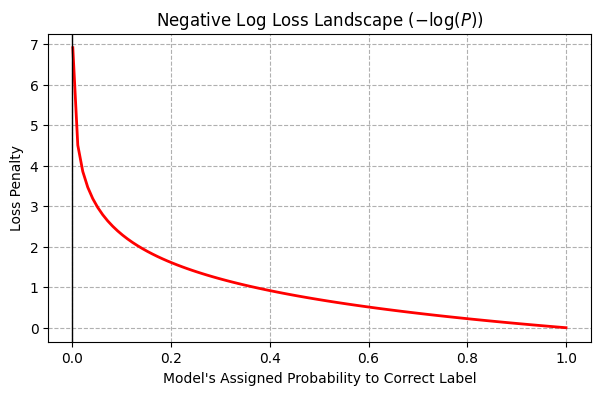

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a range of probabilities assigned to the correct class label (from 0.01 to 1.0)
p_correct = np.linspace(0.001, 1.0, 100)
loss = -np.log(p_correct)

# Print a tracking matrix showing how the penalty escalates dramatically for low probabilities
print("Probability Assigned to Correct Class vs. Resulting Log Penalty:")
print("-" * 65)
check_points = [1.0, 0.9, 0.5, 0.1, 0.01, 0.001]
for p in check_points:
    print(f"Confidence: {p*100:6.1f}%  |  P(correct) = {p:.3f}  |  Calculated Loss = {-np.log(p):.4f}")

# Optional: Plotting the loss response landscape to visualize the exponential wall
plt.figure(figsize=(7, 4))
plt.plot(p_correct, loss, color='red', lw=2)
plt.title("Negative Log Loss Landscape ($-\log(P)$)")
plt.xlabel("Model's Assigned Probability to Correct Label")
plt.ylabel("Loss Penalty")
plt.grid(True, linestyle='--')
plt.axvline(0, color='black',lw=1)
plt.show()

### Day 5 — Linear Algebra for ML
1. Dot Product
2. Matrix Multiplication
3. Cross Product
4. Useful Linear Algebra Functions
    <!-- np.linalg.norm()
    np.linalg.inv()
    np.linalg.det()
    np.linalg.eig() -->

In [14]:
# np.zeros((3, 3))
# np.ones((2, 2))
# np.full((2, 2), 5)
# np.eye(3)
# np.random.randn(3, 4)
# np.arange(10)
# np.linspace(0, 1, 5)

# a.shape
# a.ndim
# a.size
# a.dtype

# a.reshape(2, 3)
# a.flatten()
# a.T